In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from data import load_data

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]

df_coded = df.copy()[genes]
mask_nontrivial = []
for gene in genes:
    col = df[gene]
    cnt_a, cnt_c, cnt_g, cnt_t = [col.str.count(char) for char in 'ACGT']
    df_coded[gene] = (cnt_a*27 + cnt_c*9 + cnt_g*3 + cnt_t).astype(np.float32)
    mask_nontrivial += [cnt.nunique() for cnt in [cnt_a, cnt_c, cnt_g, cnt_t]]
mask_nontrivial = np.array(mask_nontrivial) > 1

np.seterr(invalid='ignore')

class DFTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, goal, columns=genes):
        super().__init__()
        if goal == 'cat':
            self.inner_tfmer = OrdinalEncoder().fit(df_coded.loc[:, columns])
        elif goal == 'oh':
            self.inner_tfmer = OneHotEncoder(sparse=False).fit(df_coded.loc[:, columns])
        elif goal == 'num':
            self.inner_tfmer = FunctionTransformer().fit(df_coded)
        self.goal = goal
        if columns is None:
            columns = np.full((len(genes), ), True)
        self.columns = columns
    
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return self.inner_tfmer.transform(self._pretransform(X))

    def _pretransform(self, X):
        if not isinstance(self.inner_tfmer, FunctionTransformer):
            return X.values
        else:
            arr = np.where(X.values != 0, X.values, np.nan)
            result_a, arr = np.divmod(arr, 27)
            result_c, arr = np.divmod(arr, 9)
            result_g, result_t = np.divmod(arr, 3)
            result = np.stack([result_a, result_c, result_g, result_t], axis=-1).reshape(arr.shape[0], -1)
            return result[:, mask_nontrivial]
            
def cv_splitter(X, y, n_splits, shuffle=True, random_state=None):
    for train_idxs, test_idxs in StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state).split(X, y):
        yield X.iloc[train_idxs], X.iloc[test_idxs], y[train_idxs], y[test_idxs]

In [2]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline

n_splits = 5
work_log_ = dict()

In [16]:
y = df['Geographic region']

In [17]:
from sklearn.naive_bayes import CategoricalNB

min_categories = df[genes].nunique(dropna=False).values
for i, (X_train, X_test, y_train, y_test) in enumerate(cv_splitter(df_coded, y, n_splits=n_splits, random_state=42)):
    model = make_pipeline(
        DFTransformer(goal='cat'),
        CategoricalNB(
            alpha=1.,
            min_categories=min_categories
        )
    )
    model.fit(X_train, y_train)
    work_log_[f'CatNB_train_{i}'] = model.predict(X_train)
    work_log_[f'CatNB_test_{i}' ] = model.predict(X_test )

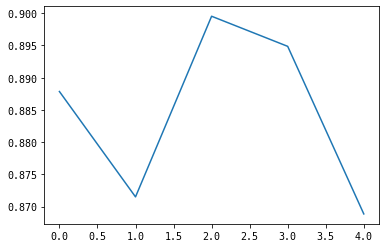

In [18]:
acc = [
    accuracy_score(y_test, work_log_[f'CatNB_test_{i}'])
    for i, (_, _, _, y_test) in enumerate(cv_splitter(df_coded, y, n_splits=n_splits, random_state=42))
]
plt.plot(range(n_splits), acc)